# TO DO

- plot data on a background map for better context/visualization
- plot multiple timesteps for a time series (use an mean of data from each date?)
- update front matter (title, description, authors, links)


# ICESat-2 ATL13

This tutorial is...

## Lake Mead

ATL13 Product

https://nsidc.org/sites/nsidc.org/files/technical-references/ICESat2_ATL13_data_dict_v003.pdf

### import required packages

In [41]:
import icepyx as ipx

import h5py
import geopandas as gpd
import pandas as pd

In [2]:
ipx.__version__

'2.0.1.dev23+g06cbc7dec.d20251118'

In [3]:
spatial_extent = [-114.6, 36.06, -114.36, 36.2] #lower left lon, lat, upper right lon, lat
dates = ['2019-07-01', '2025-07-30']
track = ['341']

In [4]:
mead = ipx.Query('ATL13', spatial_extent, dates, tracks=track)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
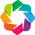

:Overlay
   .WMTS.I :WMTS   [Longitude,Latitude]
   .Path.I :Path   [Longitude,Latitude]

In [5]:
mead.visualize_spatial_extent()

In [6]:
mead.avail_granules(ids=True)

[['ATL13_20190720093743_03410401_006_01.h5',
  'ATL13_20191019051745_03410501_006_01.h5',
  'ATL13_20200118005729_03410601_006_01.h5',
  'ATL13_20200417203718_03410701_006_01.h5',
  'ATL13_20200717161706_03410801_006_01.h5',
  'ATL13_20201016115651_03410901_006_01.h5',
  'ATL13_20210115073646_03411001_006_01.h5',
  'ATL13_20210416031637_03411101_006_01.h5',
  'ATL13_20210715225628_03411201_006_01.h5',
  'ATL13_20211014183626_03411301_006_01.h5',
  'ATL13_20220113141619_03411401_006_01.h5',
  'ATL13_20220414095539_03411501_006_01.h5',
  'ATL13_20220714053608_03411601_006_01.h5',
  'ATL13_20221013011555_03411701_006_01.h5',
  'ATL13_20230111205537_03411801_006_02.h5',
  'ATL13_20230412163520_03411901_006_02.h5',
  'ATL13_20230712121442_03412001_006_02.h5',
  'ATL13_20231011075401_03412101_006_02.h5',
  'ATL13_20240110033348_03412201_006_01.h5',
  'ATL13_20240409231316_03412301_006_01.h5',
  'ATL13_20240709185245_03412401_006_01.h5',
  'ATL13_20241008143234_03412501_006_01.h5',
  'ATL13_2

In [7]:
mead.order_granules()

Harmony job ID:  6af25ca7-d804-49de-af6f-7ff5acedb413
Initial status of your harmony order request: running


Job ID,Type,Status,Details
6af25ca7-d804-49de-af6f-7ff5acedb413,subset,running,View Details


In [9]:
#Download the data
mead.download_granules('lakemead')

Your harmony job status is still running. Please continue waiting... this may take a few moments.
...............................................................................................................................................................................................Downloading results for harmony job 6af25ca7-d804-49de-af6f-7ff5acedb413
lakemead/130779889_ATL13_20190720093743_03410401_007_01_subsetted.h5
lakemead/130779892_ATL13_20200417203718_03410701_007_01_subsetted.h5
lakemead/130779891_ATL13_20200118005729_03410601_007_01_subsetted.h5
lakemead/130779893_ATL13_20200717161706_03410801_007_01_subsetted.h5
lakemead/130779894_ATL13_20201016115651_03410901_007_01_subsetted.h5
lakemead/130779895_ATL13_20210115073646_03411001_007_01_subsetted.h5
lakemead/130779896_ATL13_20210416031637_03411101_007_01_subsetted.h5
lakemead/130779898_ATL13_20211014183626_03411301_007_01_subsetted.h5
lakemead/130779897_ATL13_20210715225628_03411201_007_01_subsetted.h5
lakemead/13077990

[PosixPath('lakemead/130779889_ATL13_20190720093743_03410401_007_01_subsetted.h5'),
 PosixPath('lakemead/130779892_ATL13_20200417203718_03410701_007_01_subsetted.h5'),
 PosixPath('lakemead/130779891_ATL13_20200118005729_03410601_007_01_subsetted.h5'),
 PosixPath('lakemead/130779893_ATL13_20200717161706_03410801_007_01_subsetted.h5'),
 PosixPath('lakemead/130779894_ATL13_20201016115651_03410901_007_01_subsetted.h5'),
 PosixPath('lakemead/130779895_ATL13_20210115073646_03411001_007_01_subsetted.h5'),
 PosixPath('lakemead/130779896_ATL13_20210416031637_03411101_007_01_subsetted.h5'),
 PosixPath('lakemead/130779898_ATL13_20211014183626_03411301_007_01_subsetted.h5'),
 PosixPath('lakemead/130779897_ATL13_20210715225628_03411201_007_01_subsetted.h5'),
 PosixPath('lakemead/130779900_ATL13_20220414095539_03411501_007_01_subsetted.h5'),
 PosixPath('lakemead/130779901_ATL13_20220714053608_03411601_007_01_subsetted.h5'),
 PosixPath('lakemead/130779903_ATL13_20230111205537_03411801_007_01_subsette

read data in

In [47]:
path_root = 'lakemead'
reader = ipx.Read(path_root)
reader.filelist

['lakemead/130779897_ATL13_20210715225628_03411201_007_01_subsetted.h5',
 'lakemead/130779903_ATL13_20230111205537_03411801_007_01_subsetted.h5',
 'lakemead/130779896_ATL13_20210416031637_03411101_007_01_subsetted.h5',
 'lakemead/130779905_ATL13_20230712121442_03412001_007_01_subsetted.h5',
 'lakemead/130779904_ATL13_20230412163520_03411901_007_01_subsetted.h5',
 'lakemead/130779902_ATL13_20221013011555_03411701_007_01_subsetted.h5',
 'lakemead/130779912_ATL13_20250408055206_03412701_007_01_subsetted.h5',
 'lakemead/130779894_ATL13_20201016115651_03410901_007_01_subsetted.h5',
 'lakemead/130779898_ATL13_20211014183626_03411301_007_01_subsetted.h5',
 'lakemead/130779891_ATL13_20200118005729_03410601_007_01_subsetted.h5',
 'lakemead/130779901_ATL13_20220714053608_03411601_007_01_subsetted.h5',
 'lakemead/130779907_ATL13_20240110033348_03412201_007_01_subsetted.h5',
 'lakemead/130779909_ATL13_20240709185245_03412401_007_01_subsetted.h5',
 'lakemead/130779900_ATL13_20220414095539_03411501_

In [14]:
reader.variables.append(var_list=["segment_lat", "segment_lon", 'ht_ortho'])

In [46]:
wanted = reader.variables.wanted
wanted

{'segment_lat': ['gt1l/segment_lat',
  'gt1r/segment_lat',
  'gt2l/segment_lat',
  'gt2r/segment_lat',
  'gt3l/segment_lat',
  'gt3r/segment_lat'],
 'segment_lon': ['gt1l/segment_lon',
  'gt1r/segment_lon',
  'gt2l/segment_lon',
  'gt2r/segment_lon',
  'gt3l/segment_lon',
  'gt3r/segment_lon'],
 'ht_ortho': ['gt1l/ht_ortho',
  'gt1r/ht_ortho',
  'gt2l/ht_ortho',
  'gt2r/ht_ortho',
  'gt3l/ht_ortho',
  'gt3r/ht_ortho']}

In [37]:
def read_file(file_path):
    '''
    Read in all beams for a single file
    
    Returns
    -------
    Pandas dataframe with all latitude, longitude, and height values
    '''
    with h5py.File(file_path, 'r') as f:    
        for k,v in wanted.items():
            gt1l = pd.DataFrame(data={k: f[wanted[k][0]][:] for k in wanted.keys()})
            gt1r = pd.DataFrame(data={k: f[wanted[k][1]][:] for k in wanted.keys()})
            gt2l = pd.DataFrame(data={k: f[wanted[k][2]][:] for k in wanted.keys()})
            gt2r = pd.DataFrame(data={k: f[wanted[k][3]][:] for k in wanted.keys()})
            gt3l = pd.DataFrame(data={k: f[wanted[k][4]][:] for k in wanted.keys()})
            gt3r = pd.DataFrame(data={k: f[wanted[k][5]][:] for k in wanted.keys()})
            
    return pd.concat([gt1l, gt1r, gt2l, gt2r, gt3l, gt3r])        

In [45]:
#TODO: read in more than one file, which will require adding a date ID to the data, to have a time series

# for file_path in reader.filelist[0]:
#     print(file_path)
file_path=reader.filelist[0]
    # Open the file and read the data
    # need to add date to the data!
file_data = read_file(file_path)

In [39]:
file_data

,segment_lat,segment_lon,ht_ortho
0,36.146311,-114.545224,325.645599
1,36.146553,-114.545252,325.646820
2,36.146725,-114.545272,325.622345
3,36.146922,-114.545295,325.589264
4,36.147063,-114.545311,325.587921
...,...,...,...
633,36.154541,-114.473680,325.574188
634,36.154598,-114.473687,325.586243
635,36.154656,-114.473693,325.586273
636,36.154713,-114.473700,325.565643


In [42]:
geometry = gpd.points_from_xy(file_data.segment_lat, file_data.segment_lon )#, crs="EPSG:4326")


gdf = gpd.GeoDataFrame(file_data, geometry=geometry)

In [ ]:
# TODO: add a background map; color the points by height and add a legend

<Axes: >

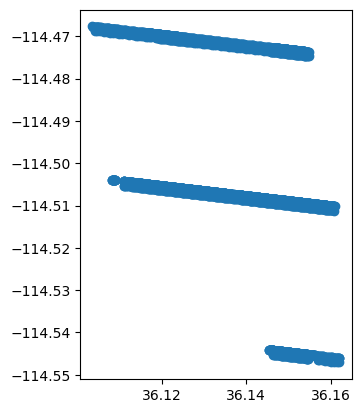

In [44]:
gdf.plot()

### Other things to consider
This example neglects many critical steps required for a robust scientific analysis:
- coordinate reference systems (CRS), the horizontal projection of the data
- datum, the vertical reference frame, which may require corrections if combining with other datasets
- spatial filtering to remove points that fall on land